# Detección de tráfico DDoS mediante comportamiento de flujo de red

## Pregunta de investigación

> **Can flow-level network behavior distinguish benign traffic from DDoS traffic?**

## Objetivo

Implementar y evaluar modelos de clasificación supervisada capaces de distinguir entre tráfico benigno y tráfico DDoS utilizando características de flujo de red del dataset CICIDS2017.

## Enfoque

El problema se plantea como una **clasificación binaria**:

- `0` = BENIGN  
- `1` = DDoS

Se evaluarán modelos supervisados usando **accuracy**, **precision**, **recall**, **F1-score**, **matriz de confusión** y **curva ROC**.

---
## Justificación del dataset

Durante la fase inicial del proyecto se identificó una limitación metodológica en el dataset originalmente seleccionado: los registros disponibles correspondían únicamente a interacciones sospechosas o maliciosas, sin una clase explícita de tráfico benigno. Esto impedía construir un clasificador supervisado válido para diferenciar entre tráfico normal y tráfico malicioso.

Por esta razón, se decidió utilizar el dataset **CICIDS2017**, específicamente el archivo correspondiente al tráfico de viernes por la tarde con ataques DDoS. Este dataset contiene tráfico benigno y tráfico DDoS etiquetado, lo cual permite reformular el problema como una clasificación binaria: `BENIGN` vs `DDoS`.

Esta reformulación mantiene el enfoque original del proyecto en detección de amenazas mediante ciencia de datos, pero corrige la debilidad metodológica del dataset inicial y permite evaluar modelos supervisados mediante métricas estándar.

---
## 1. Imports

In [1]:
import os
import warnings

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    roc_auc_score,
)

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)

---
## 2. Carga del dataset

In [2]:
DATA_PATH = os.path.join(
    "data",
    "Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv"
)

df = pd.read_csv(DATA_PATH)

print("Dataset loaded successfully.")
print("Shape:", df.shape)

df.head()

Dataset loaded successfully.
Shape: (225745, 79)


,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,Bwd Packet Length Max,Bwd Packet Length Min,Bwd Packet Length Mean,Bwd Packet Length Std,Flow Bytes/s,Flow Packets/s,Flow IAT Mean,Flow IAT Std,Flow IAT Max,Flow IAT Min,Fwd IAT Total,Fwd IAT Mean,Fwd IAT Std,Fwd IAT Max,Fwd IAT Min,Bwd IAT Total,Bwd IAT Mean,Bwd IAT Std,Bwd IAT Max,Bwd IAT Min,Fwd PSH Flags,Bwd PSH Flags,Fwd URG Flags,Bwd URG Flags,Fwd Header Length,Bwd Header Length,Fwd Packets/s,Bwd Packets/s,Min Packet Length,Max Packet Length,Packet Length Mean,Packet Length Std,Packet Length Variance,FIN Flag Count,SYN Flag Count,RST Flag Count,PSH Flag Count,ACK Flag Count,URG Flag Count,CWE Flag Count,ECE Flag Count,Down/Up Ratio,Average Packet Size,Avg Fwd Segment Size,Avg Bwd Segment Size,Fwd Header Length.1,Fwd Avg Bytes/Bulk,Fwd Avg Packets/Bulk,Fwd Avg Bulk Rate,Bwd Avg Bytes/Bulk,Bwd Avg Packets/Bulk,Bwd Avg Bulk Rate,Subflow Fwd Packets,Subflow Fwd Bytes,Subflow Bwd Packets,Subflow Bwd Bytes,Init_Win_bytes_forward,Init_Win_bytes_backward,act_data_pkt_fwd,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,54865,3,2,0,12,0,6,6,6.0,0.0,0,0,0.0,0.0,4.000000e+06,666666.66670,3.0,0.0,3,3,3,3.0,0.0,3,3,0,0.0,0.0,0,0,0,0,0,0,40,0,666666.666700,0.000000,6,6,6.0,0.0,0.0,0,0,0,0,1,0,0,0,0,9.0,6.0,0.0,40,0,0,0,0,0,0,2,12,0,0,33,-1,1,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
1,55054,109,1,1,6,6,6,6,6.0,0.0,6,6,6.0,0.0,1.100917e+05,18348.62385,109.0,0.0,109,109,0,0.0,0.0,0,0,0,0.0,0.0,0,0,0,0,0,0,20,20,9174.311927,9174.311927,6,6,6.0,0.0,0.0,0,0,0,0,1,1,0,0,1,9.0,6.0,6.0,20,0,0,0,0,0,0,1,6,1,6,29,256,0,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
2,55055,52,1,1,6,6,6,6,6.0,0.0,6,6,6.0,0.0,2.307692e+05,38461.53846,52.0,0.0,52,52,0,0.0,0.0,0,0,0,0.0,0.0,0,0,0,0,0,0,20,20,19230.769230,19230.769230,6,6,6.0,0.0,0.0,0,0,0,0,1,1,0,0,1,9.0,6.0,6.0,20,0,0,0,0,0,0,1,6,1,6,29,256,0,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
3,46236,34,1,1,6,6,6,6,6.0,0.0,6,6,6.0,0.0,3.529412e+05,58823.52941,34.0,0.0,34,34,0,0.0,0.0,0,0,0,0.0,0.0,0,0,0,0,0,0,20,20,29411.764710,29411.764710,6,6,6.0,0.0,0.0,0,0,0,0,1,1,0,0,1,9.0,6.0,6.0,20,0,0,0,0,0,0,1,6,1,6,31,329,0,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
4,54863,3,2,0,12,0,6,6,6.0,0.0,0,0,0.0,0.0,4.000000e+06,666666.66670,3.0,0.0,3,3,3,3.0,0.0,3,3,0,0.0,0.0,0,0,0,0,0,0,40,0,666666.666700,0.000000,6,6,6.0,0.0,0.0,0,0,0,0,1,0,0,0,0,9.0,6.0,0.0,40,0,0,0,0,0,0,2,12,0,0,32,-1,1,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN


---
## 3. Normalización de nombres de columnas

Los CSV de CICIDS2017 suelen traer espacios en los nombres de columna. Esta celda los elimina.

In [3]:
df.columns = df.columns.str.strip()

print("Columns:")
print(df.columns.tolist())

Columns:
['Destination Port', 'Flow Duration', 'Total Fwd Packets', 'Total Backward Packets', 'Total Length of Fwd Packets', 'Total Length of Bwd Packets', 'Fwd Packet Length Max', 'Fwd Packet Length Min', 'Fwd Packet Length Mean', 'Fwd Packet Length Std', 'Bwd Packet Length Max', 'Bwd Packet Length Min', 'Bwd Packet Length Mean', 'Bwd Packet Length Std', 'Flow Bytes/s', 'Flow Packets/s', 'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min', 'Fwd IAT Total', 'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max', 'Fwd IAT Min', 'Bwd IAT Total', 'Bwd IAT Mean', 'Bwd IAT Std', 'Bwd IAT Max', 'Bwd IAT Min', 'Fwd PSH Flags', 'Bwd PSH Flags', 'Fwd URG Flags', 'Bwd URG Flags', 'Fwd Header Length', 'Bwd Header Length', 'Fwd Packets/s', 'Bwd Packets/s', 'Min Packet Length', 'Max Packet Length', 'Packet Length Mean', 'Packet Length Std', 'Packet Length Variance', 'FIN Flag Count', 'SYN Flag Count', 'RST Flag Count', 'PSH Flag Count', 'ACK Flag Count', 'URG Flag Count', 'CWE Flag Count', 'ECE F

---
## 4. Análisis exploratorio

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 225745 entries, 0 to 225744
Data columns (total 79 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   Destination Port             225745 non-null  int64  
 1   Flow Duration                225745 non-null  int64  
 2   Total Fwd Packets            225745 non-null  int64  
 3   Total Backward Packets       225745 non-null  int64  
 4   Total Length of Fwd Packets  225745 non-null  int64  
 5   Total Length of Bwd Packets  225745 non-null  int64  
 6   Fwd Packet Length Max        225745 non-null  int64  
 7   Fwd Packet Length Min        225745 non-null  int64  
 8   Fwd Packet Length Mean       225745 non-null  float64
 9   Fwd Packet Length Std        225745 non-null  float64
 10  Bwd Packet Length Max        225745 non-null  int64  
 11  Bwd Packet Length Min        225745 non-null  int64  
 12  Bwd Packet Length Mean       225745 non-null  float64
 13 

In [5]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Destination Port,225745.0,8.879619e+03,1.975465e+04,0.0,80.0,80.0,80.0,65532.0
Flow Duration,225745.0,1.624165e+07,3.152437e+07,-1.0,71180.0,1452333.0,8805237.0,119999937.0
Total Fwd Packets,225745.0,4.874916e+00,1.542287e+01,1.0,2.0,3.0,5.0,1932.0
Total Backward Packets,225745.0,4.572775e+00,2.175536e+01,0.0,1.0,4.0,5.0,2942.0
Total Length of Fwd Packets,225745.0,9.394633e+02,3.249403e+03,0.0,26.0,30.0,63.0,183012.0
...,...,...,...,...,...,...,...,...
Active Min,225745.0,1.776201e+05,7.842602e+05,0.0,0.0,0.0,1862.0,100000000.0
Idle Mean,225745.0,1.032214e+07,2.185303e+07,0.0,0.0,0.0,8239725.0,120000000.0
Idle Std,225745.0,3.611943e+06,1.275689e+07,0.0,0.0,0.0,0.0,65300000.0
Idle Max,225745.0,1.287813e+07,2.692126e+07,0.0,0.0,0.0,8253838.0,120000000.0


In [6]:
print("Missing values per column:")
missing = df.isnull().sum().sort_values(ascending=False)
missing[missing > 0]

Missing values per column:


Flow Bytes/s    4
dtype: int64

Label distribution:
Label
DDoS      128027
BENIGN     97718
Name: count, dtype: int64


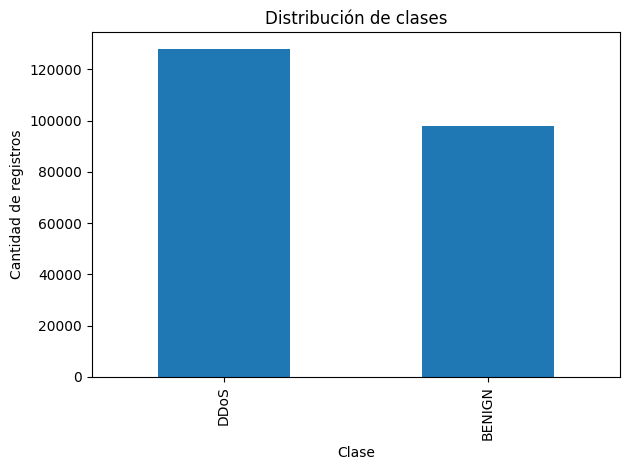

In [7]:
print("Label distribution:")
print(df["Label"].value_counts())

df["Label"].value_counts().plot(kind="bar")
plt.title("Distribución de clases")
plt.xlabel("Clase")
plt.ylabel("Cantidad de registros")
plt.tight_layout()
plt.show()

---
## 5. Limpieza de datos

CICIDS2017 contiene valores `Infinity` y divisiones problemáticas en columnas como `Flow Bytes/s`. Se eliminan valores infinitos, nulos y duplicados.

In [8]:
# Replace infinite values with NaN
df.replace([np.inf, -np.inf], np.nan, inplace=True)

# Drop rows with missing values
before_dropna = df.shape[0]
df.dropna(inplace=True)
after_dropna = df.shape[0]
print(f"Rows removed due to NaN/inf: {before_dropna - after_dropna}")

# Drop duplicate rows
before_duplicates = df.shape[0]
df.drop_duplicates(inplace=True)
after_duplicates = df.shape[0]
print(f"Duplicate rows removed: {before_duplicates - after_duplicates}")

print("Final shape after cleaning:", df.shape)

Rows removed due to NaN/inf: 34
Duplicate rows removed: 2629
Final shape after cleaning: (223082, 79)


---
## 6. Confirmar clases disponibles

In [9]:
df["Label"].value_counts()

Label
DDoS      128014
BENIGN     95068
Name: count, dtype: int64

---
## 7. Ingeniería de características — Creación del target binario

In [10]:
df["target"] = df["Label"].apply(lambda x: 0 if x == "BENIGN" else 1)

print(df[["Label", "target"]].drop_duplicates())
print()
print(df["target"].value_counts())

        Label  target
0      BENIGN       0
18883    DDoS       1

target
1    128014
0     95068
Name: count, dtype: int64


---
## 8. Separación de variables predictoras y objetivo

In [11]:
X = df.drop(columns=["Label", "target"])
y = df["target"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (223082, 78)
y shape: (223082,)


---
## 9. Selección de características — Eliminación de columnas no numéricas

In [12]:
non_numeric_cols = X.select_dtypes(exclude=[np.number]).columns.tolist()

print("Non-numeric columns:")
print(non_numeric_cols)

if len(non_numeric_cols) > 0:
    X = X.drop(columns=non_numeric_cols)
    print("Dropped non-numeric columns:", non_numeric_cols)

print("Final feature count:", X.shape[1])

Non-numeric columns:
[]
Final feature count: 78


---
## 10. Preparación de datos para modelado — Train/Test Split

In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training shape:", X_train.shape)
print("Testing shape: ", X_test.shape)
print()
print("Training class distribution:")
print(y_train.value_counts(normalize=True))
print()
print("Testing class distribution:")
print(y_test.value_counts(normalize=True))

Training shape: (178465, 78)
Testing shape:  (44617, 78)

Training class distribution:
target
1    0.573844
0    0.426156
Name: proportion, dtype: float64

Testing class distribution:
target
1    0.57384
0    0.42616
Name: proportion, dtype: float64


---
## 11. Implementación de modelos

### Modelo 1: Logistic Regression (baseline)

Modelo lineal simple, interpretable y rápido. Sirve como línea base para comparación.

In [14]:
logistic_model = Pipeline(steps=[
    ("scaler", StandardScaler()),
    ("classifier", LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        random_state=42
    ))
])

logistic_model.fit(X_train, y_train)

y_pred_lr = logistic_model.predict(X_test)
y_proba_lr = logistic_model.predict_proba(X_test)[:, 1]

In [15]:
print("=== Logistic Regression Results ===")
print(classification_report(y_test, y_pred_lr, target_names=["BENIGN", "DDoS"]))

lr_accuracy  = accuracy_score(y_test, y_pred_lr)
lr_precision = precision_score(y_test, y_pred_lr)
lr_recall    = recall_score(y_test, y_pred_lr)
lr_f1        = f1_score(y_test, y_pred_lr)
lr_auc       = roc_auc_score(y_test, y_proba_lr)

print(f"Accuracy:  {lr_accuracy:.4f}")
print(f"Precision: {lr_precision:.4f}")
print(f"Recall:    {lr_recall:.4f}")
print(f"F1-score:  {lr_f1:.4f}")
print(f"ROC-AUC:   {lr_auc:.4f}")

=== Logistic Regression Results ===
              precision    recall  f1-score   support

      BENIGN       1.00      1.00      1.00     19014
        DDoS       1.00      1.00      1.00     25603

    accuracy                           1.00     44617
   macro avg       1.00      1.00      1.00     44617
weighted avg       1.00      1.00      1.00     44617

Accuracy:  0.9986
Precision: 0.9985
Recall:    0.9990
F1-score:  0.9988
ROC-AUC:   0.9998


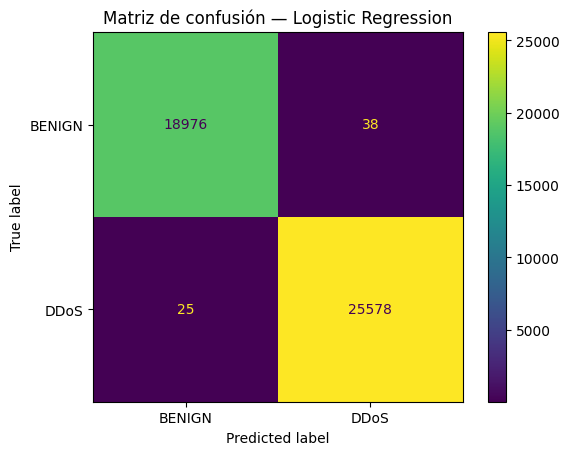

In [16]:
cm_lr = confusion_matrix(y_test, y_pred_lr)
ConfusionMatrixDisplay(confusion_matrix=cm_lr, display_labels=["BENIGN", "DDoS"]).plot()
plt.title("Matriz de confusión — Logistic Regression")
plt.show()

### Modelo 2: Random Forest

Modelo principal. Captura relaciones no lineales y permite análisis de importancia de características.

In [17]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=None,
    min_samples_split=2,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)
y_proba_rf = rf_model.predict_proba(X_test)[:, 1]

In [18]:
print("=== Random Forest Results ===")
print(classification_report(y_test, y_pred_rf, target_names=["BENIGN", "DDoS"]))

rf_accuracy  = accuracy_score(y_test, y_pred_rf)
rf_precision = precision_score(y_test, y_pred_rf)
rf_recall    = recall_score(y_test, y_pred_rf)
rf_f1        = f1_score(y_test, y_pred_rf)
rf_auc       = roc_auc_score(y_test, y_proba_rf)

print(f"Accuracy:  {rf_accuracy:.4f}")
print(f"Precision: {rf_precision:.4f}")
print(f"Recall:    {rf_recall:.4f}")
print(f"F1-score:  {rf_f1:.4f}")
print(f"ROC-AUC:   {rf_auc:.4f}")

=== Random Forest Results ===
              precision    recall  f1-score   support

      BENIGN       1.00      1.00      1.00     19014
        DDoS       1.00      1.00      1.00     25603

    accuracy                           1.00     44617
   macro avg       1.00      1.00      1.00     44617
weighted avg       1.00      1.00      1.00     44617

Accuracy:  0.9999
Precision: 1.0000
Recall:    0.9999
F1-score:  0.9999
ROC-AUC:   1.0000


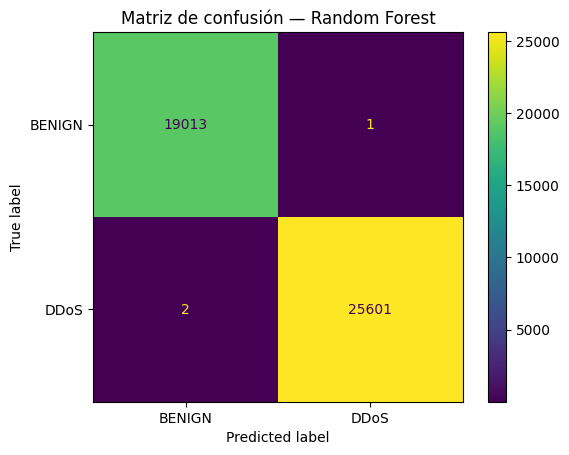

In [19]:
cm_rf = confusion_matrix(y_test, y_pred_rf)
ConfusionMatrixDisplay(confusion_matrix=cm_rf, display_labels=["BENIGN", "DDoS"]).plot()
plt.title("Matriz de confusión — Random Forest")
plt.show()

---
## 12. Comparación de modelos

In [20]:
results = pd.DataFrame({
    "Model":     ["Logistic Regression", "Random Forest"],
    "Accuracy":  [lr_accuracy,  rf_accuracy],
    "Precision": [lr_precision, rf_precision],
    "Recall":    [lr_recall,    rf_recall],
    "F1-score":  [lr_f1,        rf_f1],
    "ROC-AUC":   [lr_auc,       rf_auc],
})

results

,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,Logistic Regression,0.998588,0.998517,0.999024,0.998770,0.999808
1,Random Forest,0.999933,0.999961,0.999922,0.999941,1.000000


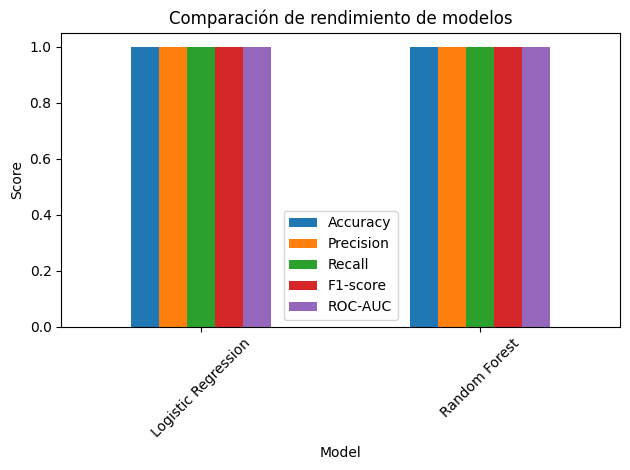

In [21]:
results.set_index("Model")[["Accuracy", "Precision", "Recall", "F1-score", "ROC-AUC"]].plot(kind="bar")
plt.title("Comparación de rendimiento de modelos")
plt.ylabel("Score")
plt.ylim(0, 1.05)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

---
## 13. Curva ROC

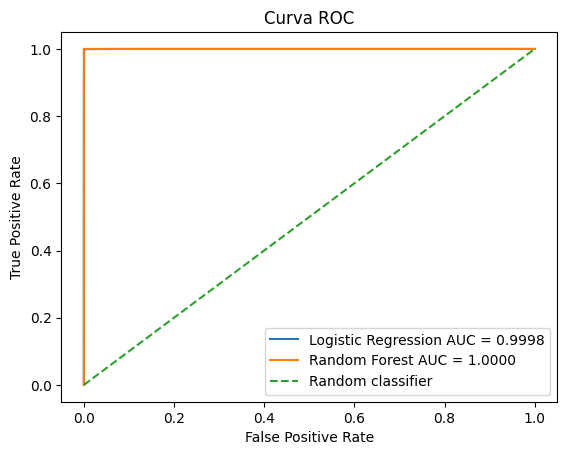

In [22]:
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_proba_lr)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_proba_rf)

plt.figure()
plt.plot(fpr_lr, tpr_lr, label=f"Logistic Regression AUC = {lr_auc:.4f}")
plt.plot(fpr_rf, tpr_rf, label=f"Random Forest AUC = {rf_auc:.4f}")
plt.plot([0, 1], [0, 1], linestyle="--", label="Random classifier")
plt.title("Curva ROC")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

---
## 14. Selección de características con Random Forest

In [23]:
feature_importances = pd.DataFrame({
    "Feature":    X_train.columns,
    "Importance": rf_model.feature_importances_
}).sort_values(by="Importance", ascending=False)

feature_importances.head(20)

,Feature,Importance
66,Init_Win_bytes_forward,0.082848
10,Bwd Packet Length Max,0.057863
8,Fwd Packet Length Mean,0.056224
53,Avg Fwd Segment Size,0.054591
6,Fwd Packet Length Max,0.053549
63,Subflow Fwd Bytes,0.050942
54,Avg Bwd Segment Size,0.043706
4,Total Length of Fwd Packets,0.040863
68,act_data_pkt_fwd,0.039932
0,Destination Port,0.033913


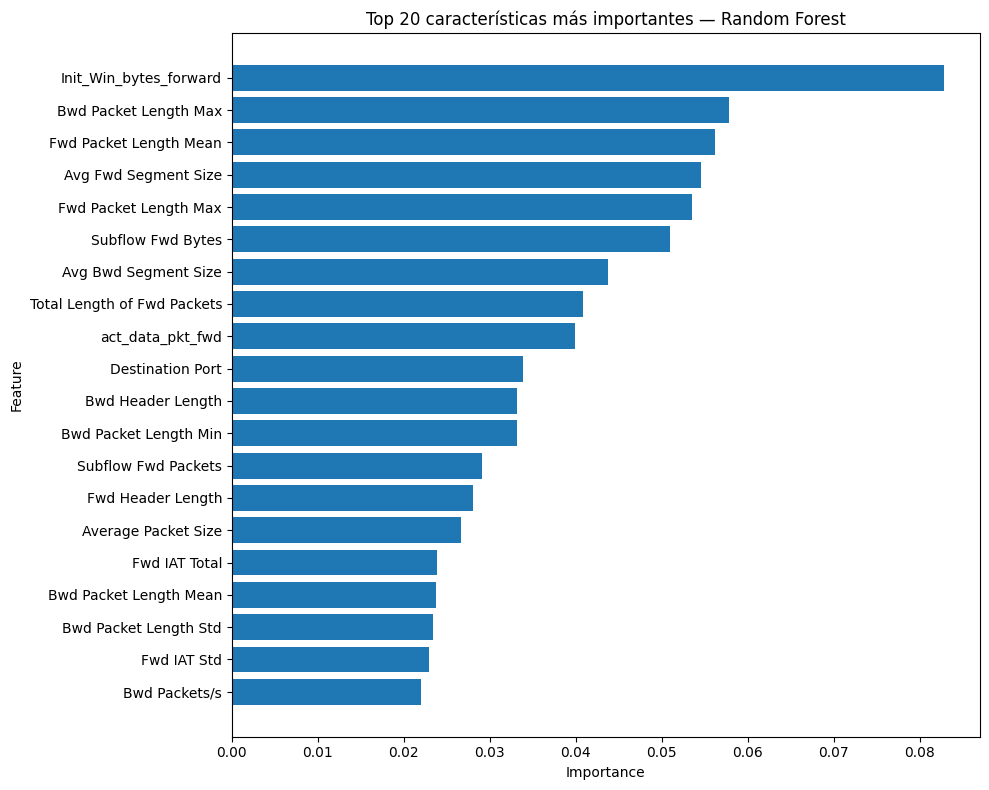

In [24]:
top_n = 20
top_features = feature_importances.head(top_n)

plt.figure(figsize=(10, 8))
plt.barh(top_features["Feature"][::-1], top_features["Importance"][::-1])
plt.title(f"Top {top_n} características más importantes — Random Forest")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

---
## 15. Refinamiento — Random Forest con Top 20 Features

Prueba si es posible mantener rendimiento similar usando menos variables. Responde directamente a la idea de _flow-level behavior_ y valida la selección de características.

In [25]:
selected_features = feature_importances.head(20)["Feature"].tolist()

X_train_selected = X_train[selected_features]
X_test_selected  = X_test[selected_features]

rf_selected_model = RandomForestClassifier(
    n_estimators=150,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

rf_selected_model.fit(X_train_selected, y_train)

y_pred_rf_selected  = rf_selected_model.predict(X_test_selected)
y_proba_rf_selected = rf_selected_model.predict_proba(X_test_selected)[:, 1]

In [26]:
print("=== Random Forest with Selected Features ===")
print(classification_report(y_test, y_pred_rf_selected, target_names=["BENIGN", "DDoS"]))

rf_selected_accuracy  = accuracy_score(y_test, y_pred_rf_selected)
rf_selected_precision = precision_score(y_test, y_pred_rf_selected)
rf_selected_recall    = recall_score(y_test, y_pred_rf_selected)
rf_selected_f1        = f1_score(y_test, y_pred_rf_selected)
rf_selected_auc       = roc_auc_score(y_test, y_proba_rf_selected)

print(f"Accuracy:  {rf_selected_accuracy:.4f}")
print(f"Precision: {rf_selected_precision:.4f}")
print(f"Recall:    {rf_selected_recall:.4f}")
print(f"F1-score:  {rf_selected_f1:.4f}")
print(f"ROC-AUC:   {rf_selected_auc:.4f}")

=== Random Forest with Selected Features ===
              precision    recall  f1-score   support

      BENIGN       1.00      1.00      1.00     19014
        DDoS       1.00      1.00      1.00     25603

    accuracy                           1.00     44617
   macro avg       1.00      1.00      1.00     44617
weighted avg       1.00      1.00      1.00     44617

Accuracy:  0.9999
Precision: 0.9998
Recall:    1.0000
F1-score:  0.9999
ROC-AUC:   1.0000


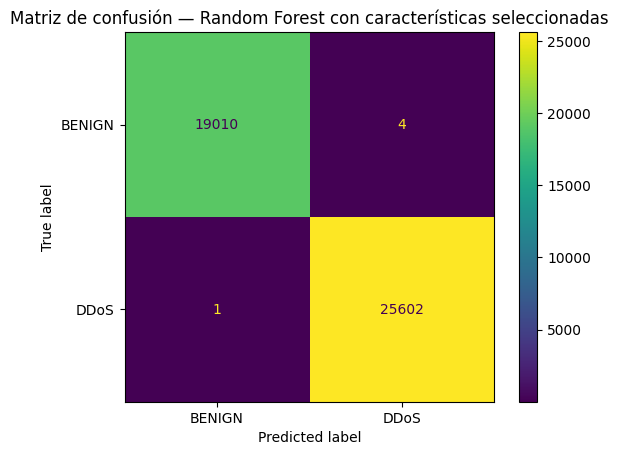

In [27]:
cm_rf_selected = confusion_matrix(y_test, y_pred_rf_selected)
ConfusionMatrixDisplay(confusion_matrix=cm_rf_selected, display_labels=["BENIGN", "DDoS"]).plot()
plt.title("Matriz de confusión — Random Forest con características seleccionadas")
plt.show()

---
## 16. Evaluación de métricas — Comparación final

In [28]:
final_results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "Random Forest — Top 20 Features"
    ],
    "Accuracy":  [lr_accuracy,  rf_accuracy,  rf_selected_accuracy],
    "Precision": [lr_precision, rf_precision, rf_selected_precision],
    "Recall":    [lr_recall,    rf_recall,    rf_selected_recall],
    "F1-score":  [lr_f1,        rf_f1,        rf_selected_f1],
    "ROC-AUC":   [lr_auc,       rf_auc,       rf_selected_auc],
})

final_results

,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,Logistic Regression,0.998588,0.998517,0.999024,0.998770,0.999808
1,Random Forest,0.999933,0.999961,0.999922,0.999941,1.000000
2,Random Forest — Top 20 Features,0.999888,0.999844,0.999961,0.999902,1.000000


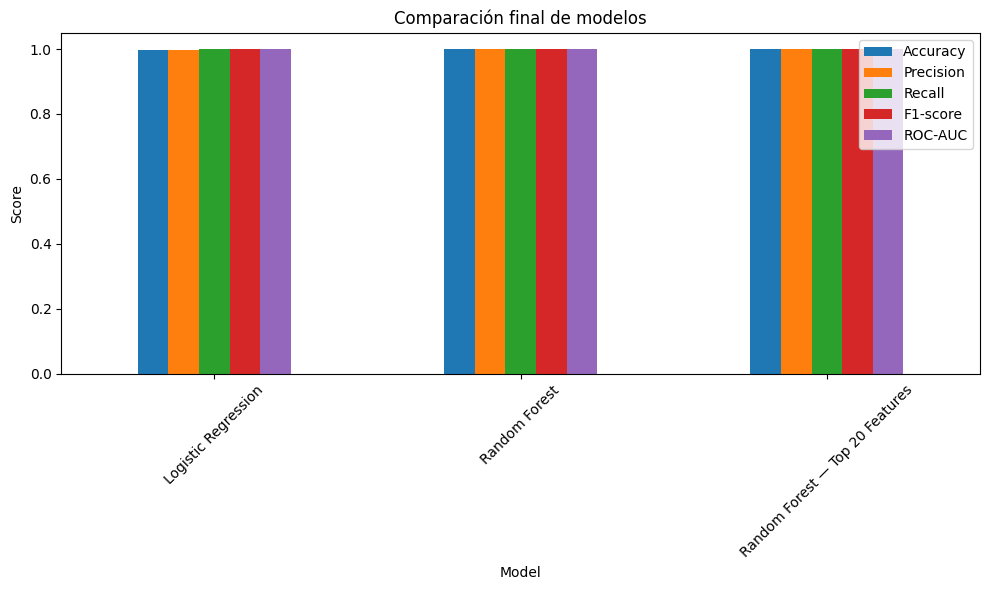

In [29]:
final_results.set_index("Model").plot(kind="bar", figsize=(10, 6))
plt.title("Comparación final de modelos")
plt.ylabel("Score")
plt.ylim(0, 1.05)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

---
## 17. Curva ROC final

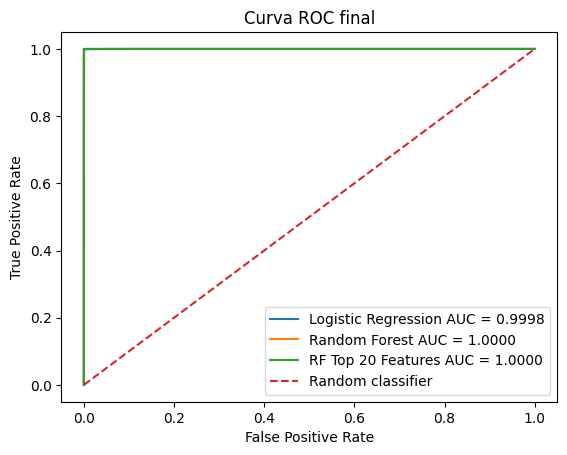

In [30]:
fpr_rf_selected, tpr_rf_selected, _ = roc_curve(y_test, y_proba_rf_selected)

plt.figure()
plt.plot(fpr_lr, tpr_lr,          label=f"Logistic Regression AUC = {lr_auc:.4f}")
plt.plot(fpr_rf, tpr_rf,          label=f"Random Forest AUC = {rf_auc:.4f}")
plt.plot(fpr_rf_selected, tpr_rf_selected, label=f"RF Top 20 Features AUC = {rf_selected_auc:.4f}")
plt.plot([0, 1], [0, 1], linestyle="--", label="Random classifier")
plt.title("Curva ROC final")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

---
## 18. Interpretación en contexto de ciberseguridad

En el contexto de detección de tráfico DDoS, las métricas no tienen el mismo peso práctico.

**Accuracy** indica el porcentaje general de clasificaciones correctas. Sin embargo, en ciberseguridad esta métrica puede ser insuficiente si existe desbalance de clases, ya que un modelo podría obtener alta accuracy clasificando correctamente la clase mayoritaria.

**Precision** indica qué proporción del tráfico clasificado como DDoS realmente corresponde a tráfico DDoS. Una precision alta reduce falsos positivos, lo cual es importante para evitar fatiga operativa en analistas de seguridad.

**Recall** indica qué proporción del tráfico DDoS real fue detectado por el modelo. En este problema, el recall es especialmente importante porque un falso negativo representa tráfico de ataque que no fue identificado.

**F1-score** combina precision y recall, permitiendo evaluar el balance entre evitar falsos positivos y detectar correctamente el tráfico malicioso.

**ROC-AUC** permite evaluar la capacidad del modelo para separar tráfico benigno y tráfico DDoS en distintos umbrales de decisión. Un ROC-AUC cercano a 1 indica alta capacidad de discriminación entre ambas clases.

---
## 19. Conclusiones

Los resultados obtenidos muestran que las características de flujo de red sí permiten distinguir entre tráfico benigno y tráfico DDoS dentro del dataset CICIDS2017. Los modelos supervisados evaluados lograron aprender patrones asociados al comportamiento del tráfico, especialmente mediante variables relacionadas con duración del flujo, volumen de paquetes, tamaño de paquetes y tasas de transferencia.

**Random Forest** presentó el mejor rendimiento general debido a su capacidad para capturar relaciones no lineales entre las características. Además, la selección de las características más importantes permitió reducir la dimensionalidad del dataset manteniendo un rendimiento competitivo, lo cual sugiere que no todas las variables disponibles aportan el mismo valor para detectar tráfico DDoS.

En el contexto de ciberseguridad, el **recall** y el **F1-score** son métricas especialmente relevantes, ya que permiten evaluar la capacidad del modelo para detectar ataques sin depender únicamente de la accuracy. Un alto recall indica que el modelo identifica correctamente la mayoría de instancias DDoS, reduciendo el riesgo de dejar pasar tráfico malicioso.